# 02 — Exploratory Data Analysis

**Dataset:** `reduced_dataset.csv`  
**Rows:** 12,111 | **Columns:** 66  
**Target:** `sold_price`  

**Notebook covers:**
- Dataset overview and schema validation
- Missing value audit
- Target variable distribution
- Listing price conversion and city-level null analysis
- Sold price by city and property type
- Feature correlations
- EDA summary

## Setup

Import libraries, load config, and read the raw dataset.

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from scipy.stats import f_oneway, ttest_ind

%run config.ipynb


df = pd.read_csv(RAW_PATH, low_memory=False)
print(f'Shape: {df.shape}')
df.head(10)

Shape: (34652, 68)


,homeData_propertyId,homeData_listingId,homeData_mlsId,homeData_url,homeData_mlsStatusId,homeData_propertyType,homeData_priceInfo_amount,homeData_priceInfo_displayLevel,homeData_priceInfo_priceType,homeData_priceInfo_homePrice_displayLevel,...,lot_size,taxes,walk_score,zolo_estimate,source,median_income,population,parking_spaces,listing_price,region
0,152867555.0,210396185.0,C12652918,/on/toronto/1741-Bayview-Ave-M4G-3C5/home/1528...,2540.0,4.0,6900000.0,1.0,1.0,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6900000.0,TORONTO
1,192254240.0,213574315.0,N12944138,/on/toronto/3-McCowan-Rd-M1M-1P1/home/192254240,4156.0,8.0,339900.0,1.0,1.0,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,459000.0,TORONTO
2,151883841.0,212786096.0,E12854246,/on/toronto/3050-Ellesmere-Rd-M1E-5E6/unit-110...,4156.0,3.0,459000.0,1.0,1.0,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,474000.0,TORONTO
3,153156878.0,209949835.0,W12637562,/on/toronto/215-Sherway-Gardens-Rd-M9C-0A4/uni...,4156.0,3.0,474000.0,1.0,1.0,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,22500000.0,TORONTO
4,151669564.0,210851260.0,C12694680,/on/toronto/45-Bayview-Ridge-M2L-1E3/home/1516...,4156.0,6.0,22500000.0,1.0,1.0,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14995000.0,TORONTO
5,181380577.0,214191127.0,C13016502,/on/toronto/36-Forest-Manor-Rd-M2J-1M1/unit-72...,4156.0,3.0,499998.0,1.0,1.0,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,28650000.0,TORONTO
6,165809261.0,213075919.0,C12885882,/on/toronto/45-Park-Lane-Cir-M3C-2N3/home/1658...,4156.0,6.0,25000000.0,1.0,1.0,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,16800000.0,TORONTO
7,152503268.0,213332012.0,C12914986,/on/toronto/85-The-Bridle-Path-M3C-2P1/home/15...,4156.0,6.0,27500000.0,1.0,1.0,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,12995000.0,TORONTO
8,152492898.0,212331248.0,C12802388,/on/toronto/50-Park-Ln-Cir-M3C-2N2/home/152492898,4156.0,6.0,14995000.0,1.0,1.0,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,429999.0,TORONTO
9,151660776.0,207902440.0,C12431780,/on/toronto/15-High-Point-Rd-M3B-2A3/home/1516...,4156.0,6.0,49950000.0,1.0,1.0,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,728000.0,TORONTO


## 1. Dataset Description

Validate the schema against config expectations, then inspect dtypes, memory usage, and a numeric summary of key columns.

In [5]:
checking_function(df, pretext='02_eda_updated_version', pre_check =True)

[02_eda_updated_version] Schema Ok shape (34652, 68)


True

In [6]:
df.info(verbose =False, memory_usage = 'deep')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 34652 entries, 0 to 34651
Columns: 68 entries, homeData_propertyId to region
dtypes: bool(1), float64(45), object(22)
memory usage: 57.0 MB


In [7]:
df[["sold_price_x", 'sold_price_y', 'bedrooms', 
    'bathrooms', 'parking_spaces', 'days_since_sold']].describe().round(5)

,sold_price_x,sold_price_y,bedrooms,bathrooms,parking_spaces,days_since_sold
count,3.465200e+04,1.208900e+04,12017.00000,12057.00000,12026.00000,33482.00000
mean,1.451864e+06,1.010564e+06,3.73496,3.08551,3.99002,354.28505
std,2.352637e+06,5.512593e+05,1.29068,1.21955,2.85346,853.31702
min,1.000000e+00,1.800000e+04,0.00000,0.00000,0.00000,0.00000
25%,7.300000e+05,7.000000e+05,3.00000,2.00000,2.00000,117.00000
50%,9.500000e+05,9.000000e+05,4.00000,3.00000,4.00000,209.00000
75%,1.302087e+06,1.182000e+06,4.00000,4.00000,5.00000,297.00000
max,4.995000e+07,1.345000e+07,12.00000,10.00000,53.00000,8474.00000


## 2. Missing Values

Audit the dataset for missing data before any transformations. This dataset has a much lower missingness rate than previous versions — maximum ~15% on `lot_size` compared to ~63% in the old merged dataset.

**Note:** `walk_score` and `zolo_estimate` are ~100% missing and will be dropped in preprocessing.

In [8]:
null_values = (df.isnull().mean()* 100).sort_values(ascending = False)
null_values_missing = null_values[null_values > 0].round(5)
print("Missing % (not zero only):")
print(null_values_missing.to_string())

Missing % (not zero only):
walk_score                              99.97114
zolo_estimate                           99.97114
lot_size                                70.22971
number_of_storeys                       65.75378
bedrooms                                65.32090
parking_spaces                          65.29493
sale_date                               65.20547
bathrooms                               65.20547
listing_date                            65.20259
source                                  65.20259
house_age                               65.20259
taxes                                   65.20259
longitude                               65.11312
latitude                                65.11312
square_feet                             65.11312
population                              65.11312
property_type                           65.11312
city                                    65.11312
address                                 65.11312
sold_price_y                            65

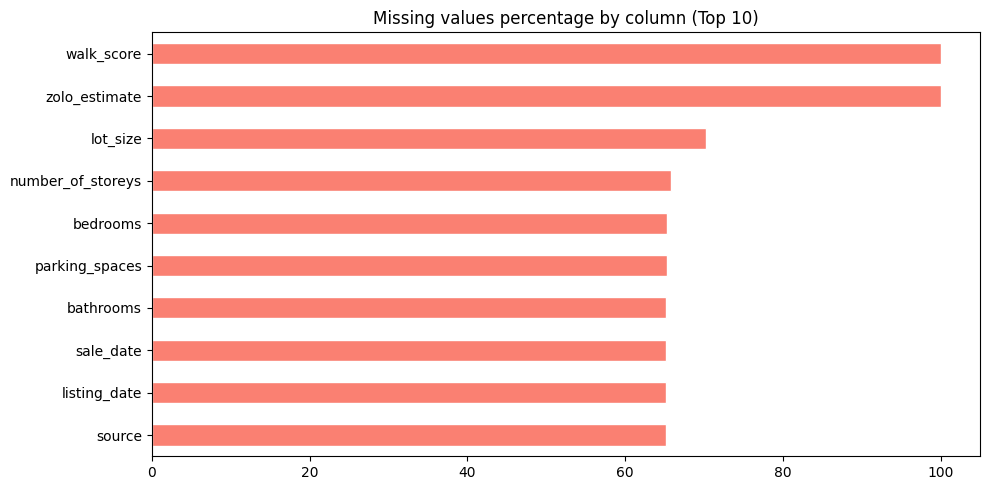

Most missing % 100.0% (walk_score)
Columns > 10% missing: 22
Columns > 50% missing: 22


In [9]:
missing_top = null_values_missing.head(10)
fig, ax = plt.subplots(figsize=(10,5))
missing_top.sort_values().plot(kind = 'barh', ax = ax, color = 'salmon', edgecolor = 'white')
ax.set_label('%Missing values')
ax.set_title("Missing values percentage by column (Top 10)")
plt.tight_layout()
plt.show()



print(f"Most missing % {null_values_missing.iloc[0]:.1f}% ({null_values_missing.index[0]})")
print(f"Columns > 10% missing: {(null_values > 10).sum()}")
print(f"Columns > 50% missing: {(null_values > 50).sum()}")

### 2.1 Key Column Missingness

Checking missingness on the columns defined in `CHECK_COL` from config — these are the columns that matter for modeling.

In [10]:
cols_audit = [i for i in CHECK_COL if i in df.columns]
print("Column is missing")
print((df[cols_audit].isnull().mean()*100).sort_values(ascending=False).round(1).to_string())

Column is missing
bedrooms          65.3
parking_spaces    65.3
bathrooms         65.2
taxes             65.2
house_age         65.2
city              65.1
property_type     65.1
latitude          65.1
population        65.1
longitude         65.1
median_income     65.1
listing_price     64.8


## 3. Target Variable — `sold_price`

The dataset has two sold price columns (`sold_price_x` and `sold_price_y`) from the two-source merge. Reconciled here using `combine_first` — `sold_price_x` takes priority. This is an EDA-only reconciliation; the official step happens in the preprocessing notebook.

In [11]:
df['sold_price'] = df['sold_price_x'].combine_first(df['sold_price_y'])

print('sold_price status:')
print(df['sold_price'].describe().apply(lambda x: f'${x:,.0f}'))
print(f'\n Remaining nulss {df['sold_price'].isnull().sum()}')

sold_price status:
count        $34,652
mean      $1,451,864
std       $2,352,637
min               $1
25%         $730,000
50%         $950,000
75%       $1,302,087
max      $49,950,000
Name: sold_price, dtype: object

 Remaining nulss 0


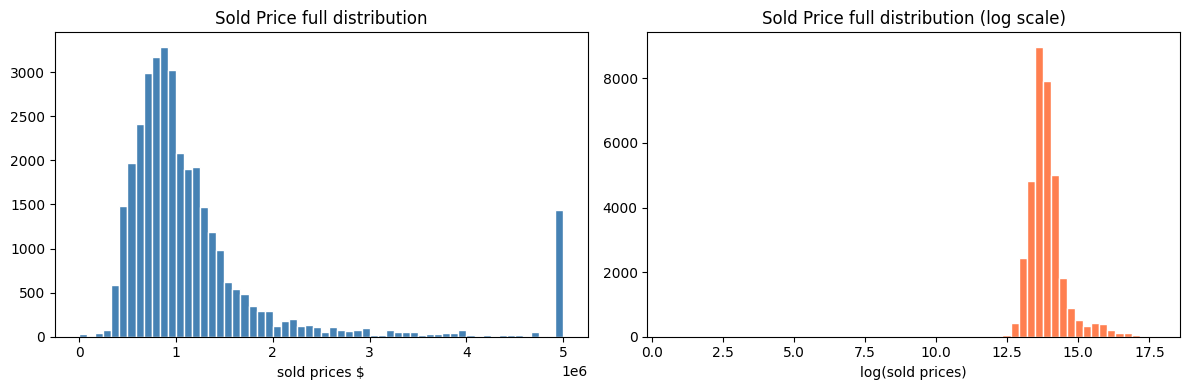

Median $950,000
Mean $1,451,864
Min $1
Max$49,950,000


In [12]:
fig, axes = plt.subplots(1,2 , figsize=(12,4))
axes[0].hist(df['sold_price'].clip(0, 5_000_000), bins = 60, color = 'steelblue', edgecolor = 'white')
axes[0].set_title("Sold Price full distribution")
axes[0].set_xlabel('sold prices $')

axes[1].hist(np.log1p(df['sold_price']), bins = 60, color = 'coral', edgecolor = 'white')
axes[1].set_title("Sold Price full distribution (log scale)")
axes[1].set_xlabel('log(sold prices)')

plt.tight_layout()
plt.show()

print(f"Median ${df['sold_price'].median():,.0f}")
print(f"Mean ${df['sold_price'].mean():,.0f}")
print(f"Min ${df['sold_price'].min():,.0f}")
print(f"Max${df['sold_price'].max():,.0f}")

## 4. Listing Price

`listing_price` comes in as a string dtype in this dataset (e.g. `'499995.0'`). Converting to float before analysis.

Also checking nulls by city — this informs the group's pending decision on whether to impute missing Toronto listing prices using Mississauga/Richmond Hill ratios or drop affected rows.

In [13]:
df['listing_price'] = df['listing_price'].apply(
    lambda x: float(x.repalce('$', "").replace(",", '')) if isinstance(x, str) else x 
).astype(float)

null_city_lp = df.groupby('city')['listing_price'].apply(
    lambda x: x.isnull().sum()).sort_values(ascending = False)
print(null_city_lp[null_city_lp > 0].to_string)

<bound method Series.to_string of Series([], Name: listing_price, dtype: int64)>


### 4.1 Listing vs Sold Price Relationship

Scatter plot of listing vs sold price with a 1:1 reference line. Points above the line sold over asking, below sold under asking. The histogram shows the distribution of percentage difference clipped to ±50%.

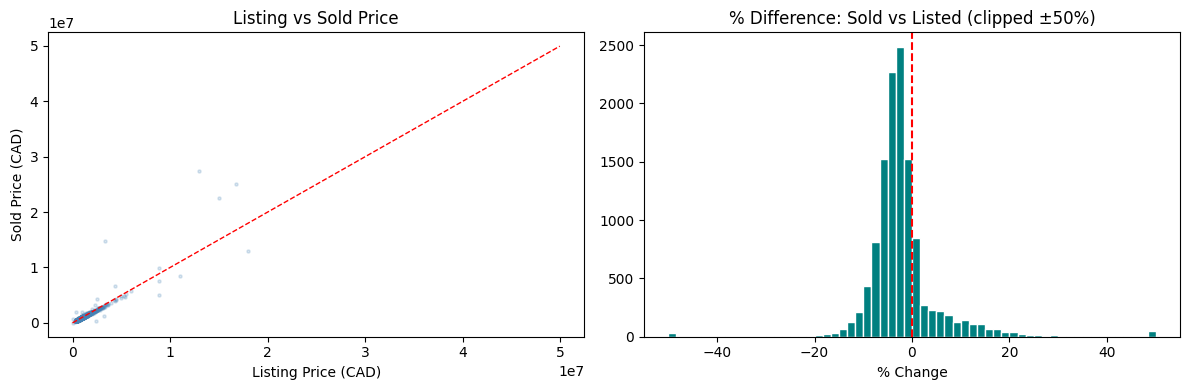

Sold above listing: 6.6%
Median price diff:  -2.99%


In [14]:
df['price_diff_pct'] = (df['sold_price'] - df['listing_price']) / df['listing_price'] * 100

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Scatter
sample = df.sample(min(5000, len(df)), random_state=42)
axes[0].scatter(sample['listing_price'], sample['sold_price'], alpha=0.2, s=5, color='steelblue')
lims = [0, df[['listing_price','sold_price']].max().max()]
axes[0].plot(lims, lims, 'r--', linewidth=1)
axes[0].set_xlabel('Listing Price (CAD)')
axes[0].set_ylabel('Sold Price (CAD)')
axes[0].set_title('Listing vs Sold Price')

# Price diff distribution
clipped = df['price_diff_pct'].clip(-50, 50)
axes[1].hist(clipped, bins=60, color='teal', edgecolor='white')
axes[1].axvline(0, color='red', linestyle='--')
axes[1].set_title('% Difference: Sold vs Listed (clipped ±50%)')
axes[1].set_xlabel('% Change')

plt.tight_layout()
plt.show()

print(f"Sold above listing: {(df['price_diff_pct'] > 0).mean()*100:.1f}%")
print(f"Median price diff:  {df['price_diff_pct'].median():.2f}%")

## 5. Sold Price by City

Comparing median and mean sold prices across the top 15 cities by listing count. This gives a sense of geographic price variation across the GTA.

In [15]:
stats_city = (df.groupby('city')['sold_price'].agg(['median','mean','count'])
              .sort_values('count', ascending = False).head(15))
print('top 15 cities by listing count:')
print(stats_city.to_string())

top 15 cities by listing count:
                  median          mean  count
city                                         
Peel            860000.0  9.495560e+05   4157
York           1100000.0  1.213106e+06   3685
Durham          795500.0  8.421792e+05   3050
Halton          902500.0  1.018397e+06   1073
Burlington     1335000.0  1.565361e+06     23
Mississauga     950000.0  9.921154e+05     13
Markham         809000.0  1.348390e+06     10
Vaughan         593750.0  9.600500e+05     10
Oshawa          397500.0  5.825000e+05      9
Pickering       545000.0  5.873897e+05      9
Richmond Hill   690000.0  8.585000e+05      8
Brampton        965000.0  1.047714e+06      7
Caledon        1450000.0  1.347143e+06      7
Halton Hills   1350000.0  1.505357e+06      7
Scugog          837500.0  9.218750e+05      4


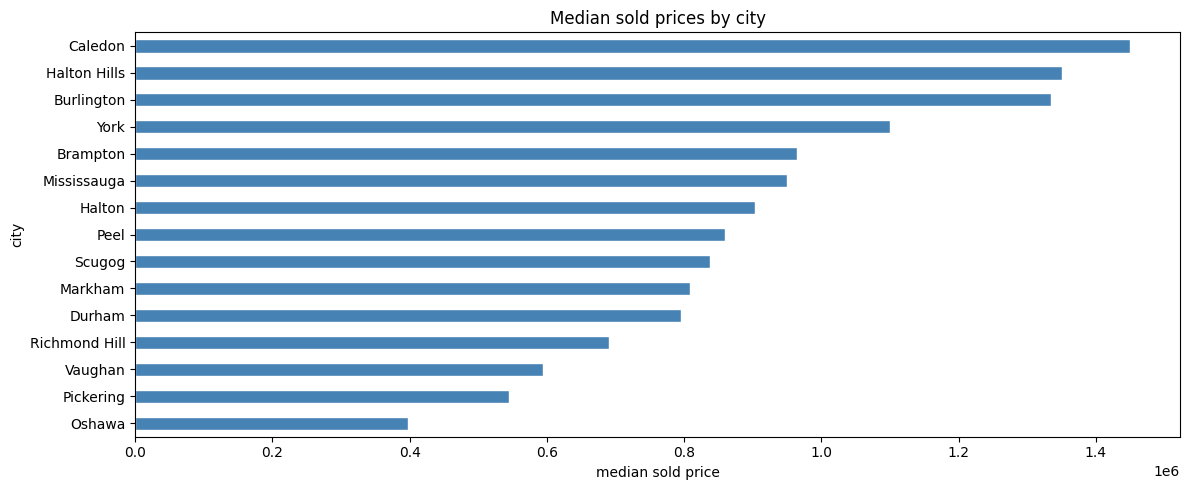

In [16]:
fig, ax = plt.subplots(figsize=(12,5))
stats_city['median'].sort_values().plot(kind = 'barh', ax = ax, color = 'steelblue', edgecolor = 'white')
ax.set_title("Median sold prices by city")
ax.set_xlabel('median sold price')
plt.tight_layout()
plt.show()

## 6. Sold Price by Property Type

Breaking down median sold prices by property type. Note: `Att/Row/Twnhouse` and `Att/Row/Townhouse` are the same category with a typo — normalized in preprocessing using `NORMLIZE_PROPERTY_TYPE` from config.

In [17]:
stats_prop = (df.groupby('property_type')['sold_price'].agg(['median','count'])
              .sort_values('count', ascending = False).head(15))

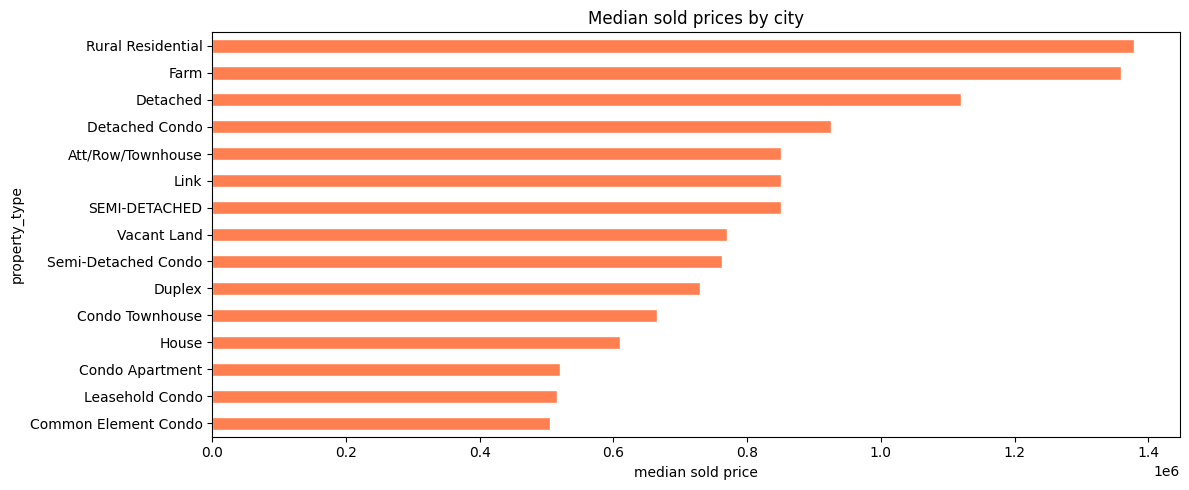

In [18]:
fig, ax = plt.subplots(figsize=(12,5))
stats_prop['median'].sort_values().plot(kind = 'barh', ax = ax, color = 'coral', edgecolor = 'white')
ax.set_title("Median sold prices by city")
ax.set_xlabel('median sold price')
plt.tight_layout()
plt.show()

## 7. Correlations with `sold_price`

Pearson correlation of all numeric features against the target. `homeData_*` columns are excluded from the plot for readability — they are dropped in preprocessing anyway.

`listing_price` is expected to dominate (~0.99 correlation) based on previous dataset analysis.

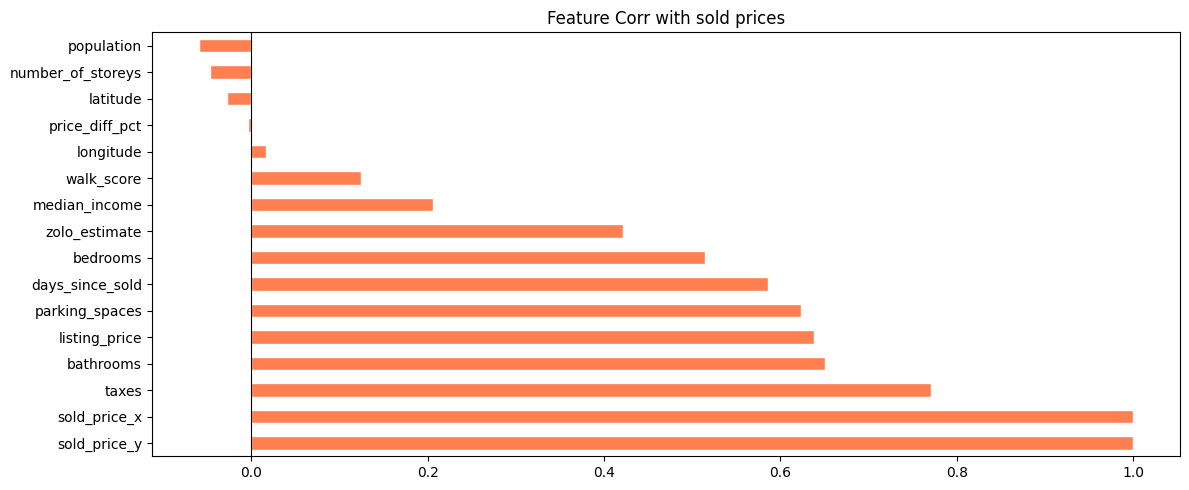

In [19]:
num_col = df.select_dtypes(include=np.number).columns
corr = df[num_col].corr()['sold_price'].drop('sold_price').sort_values(ascending=False)
corr_clean = corr.drop([i for i in corr.index if i.startswith('homeData_')], errors = 'ignore')

fig, ax = plt.subplots(figsize=(12,5))
corr_clean.plot(kind = 'barh', ax = ax, color = 'coral', edgecolor = 'white')
ax.set_title("Feature Corr with sold prices")
ax.axvline(0, color = 'black', linewidth = 0.8)
plt.tight_layout()
plt.show()

# 7.5 . ANOVA and P-Value testing



In [20]:
print("---ANOVA Feature Significane-----")

for col in CATEGORICAL_COLS:
    if col in df.columns:
        groups = [df[df[col] == cat]['sold_price']
                  for cat in df[col].dropna().unique()]
        groups =[g for g in groups if len(g) >= 2]

        f_stat, p_val = f_oneway(*groups)

        print(f'Feature: {col}  ({len(groups)} groups)')
        print(f" F-Statistic:  {f_stat:.2f}")
        print(f" P-Value:     {p_val:.4e}")

        if p_val < 0.05:
            print(f" Result: Statistically significant keep for One-hot encoding")
        else:
            print(f" Result:  Not Statistically significant,  it can (potentially) removed")
        print('-'*45)


---ANOVA Feature Significane-----
Feature: city  (20 groups)
 F-Statistic:  50.79
 P-Value:     7.3198e-185
 Result: Statistically significant keep for One-hot encoding
---------------------------------------------
Feature: property_type  (22 groups)
 F-Statistic:  182.32
 P-Value:     0.0000e+00
 Result: Statistically significant keep for One-hot encoding
---------------------------------------------


In [21]:
print("\n -----T-Test: sold above asking vs At/below asking")

above = df[df['price_diff_pct'] > 0]['sold_price']
below = df[df['price_diff_pct'] <=0]['sold_price']

t_stat, p_val = ttest_ind(above, below, equal_var = False)
print(f"Group 1 Sold above asking:  {len(above):,} listing | mean ${above.mean():,.0f}")
print(f"Group 1 Sold at/below:  {len(below):,} listing | mean ${below.mean():,.0f}")
print(f" T-stats: {t_stat:.4f}")
print(f" P-Value: {p_val:.4e}")

if p_val < 0.05:
    print(f" Result: Significant difference in sold price between groups")
else:
    print(f" Result: No signficant difference between groups")
print("-"*45)


 -----T-Test: sold above asking vs At/below asking
Group 1 Sold above asking:  2,299 listing | mean $1,194,101
Group 1 Sold at/below:  9,902 listing | mean $1,036,658
 T-stats: 3.6353
 P-Value: 2.8351e-04
 Result: Significant difference in sold price between groups
---------------------------------------------


## 8. EDA Summary

Key statistics from the full EDA pass. These figures inform preprocessing thresholds and feature engineering decisions.

In [22]:
print('=== EDA Summary ===')
print(f"Total listings:          {len(df):,}")
print(f"Median sold price:       ${df['sold_price'].median():,.0f}")
print(f"Mean sold price:         ${df['sold_price'].mean():,.0f}")
print(f"Sold above listing:      {(df['price_diff_pct'] > 0).mean()*100:.1f}%")
print(f"Median price diff:       {df['price_diff_pct'].median():.2f}%")
print(f"Most common city:        {df['city'].mode()[0]}")
print(f"Most common type:        {df['property_type'].mode()[0]}")
print(f"Corr listing\u2192sold:       {df['listing_price'].corr(df['sold_price']):.4f}")
print(f"Corr bedrooms\u2192sold:      {df['bedrooms'].corr(df['sold_price']):.4f}")

=== EDA Summary ===
Total listings:          34,652
Median sold price:       $950,000
Mean sold price:         $1,451,864
Sold above listing:      6.6%
Median price diff:       -2.99%
Most common city:        Peel
Most common type:        Detached
Corr listing→sold:       0.6380
Corr bedrooms→sold:      0.5149
